# Radiation & Environmental Sensor Lab Analysis
**MSE 45L / Physics Lab — Statistical Analysis of Counting Data**

### How to use this notebook
1. Put your session files in the same folder as this notebook (or update the paths below)
2. Run all cells top to bottom
3. All plots and statistics will regenerate automatically

Required files: `radiation.csv`, `pth.csv`, `air_quality.csv`, `session.json`

In [ ]:
# IMPORTS

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

print('Imports OK')

Matplotlib is building the font cache; this may take a moment.


In [ ]:
cwd = Path.cwd()
pcwd = cwd.parent

RADIATION_FILE   = pcwd / 'datafolder' / 'radiation.csv'
PTH_FILE         = pcwd / 'datafolder' / 'pth.csv'          # pressure / temperature / humidity
AIR_QUALITY_FILE = pcwd / 'datafolder' / 'air_quality.csv'
SESSION_FILE     = pcwd / 'datafolder' / 'session.json'

print('All good so far')

# Integration time per measurement, but can override here:
INTEGRATION_TIME_OVERRIDE = None

All good so far


In [ ]:
with open(SESSION_FILE) as f:
    session = json.load(f)

T_int = INTEGRATION_TIME_OVERRIDE or session['integration_times'][0]
print(f"Session: {session['start_time']} → {session['end_time']}")
print(f"Sensors: {session['sensors_activated']}")
print(f"Integration time: {T_int} s")

rad = pd.read_csv(RADIATION_FILE)
pth = pd.read_csv(PTH_FILE)
aq  = pd.read_csv(AIR_QUALITY_FILE)

# Convert epoch timestamps to elapsed seconds from start of session
t0 = rad['timestamp'].min()
for df in [rad, pth, aq]:
    df['t'] = df['timestamp'] - t0

# Raw counts per integration window (for Poisson statistics)
rad['counts'] = rad['cps'] * T_int

print(f"\nData loaded:")
print(f"  Radiation: {len(rad)} measurements, duration {rad['t'].max():.1f} s")
print(f"  PTH:       {len(pth)} measurements")
print(f"  Air quality: {len(aq)} measurements")

Session: 2026-04-16_16-39-23 → 2026-04-16_16-47-50
Sensors: ['Radiation', 'Air Quality', 'P/T/H']
Integration time: 10 s

Data loaded:
  Radiation: 250 measurements, duration 501.8 s
  PTH:       241 measurements
  Air quality: 127 measurements


---
## Plot 1 — Time series: Radiation, Temperature, PM2.5

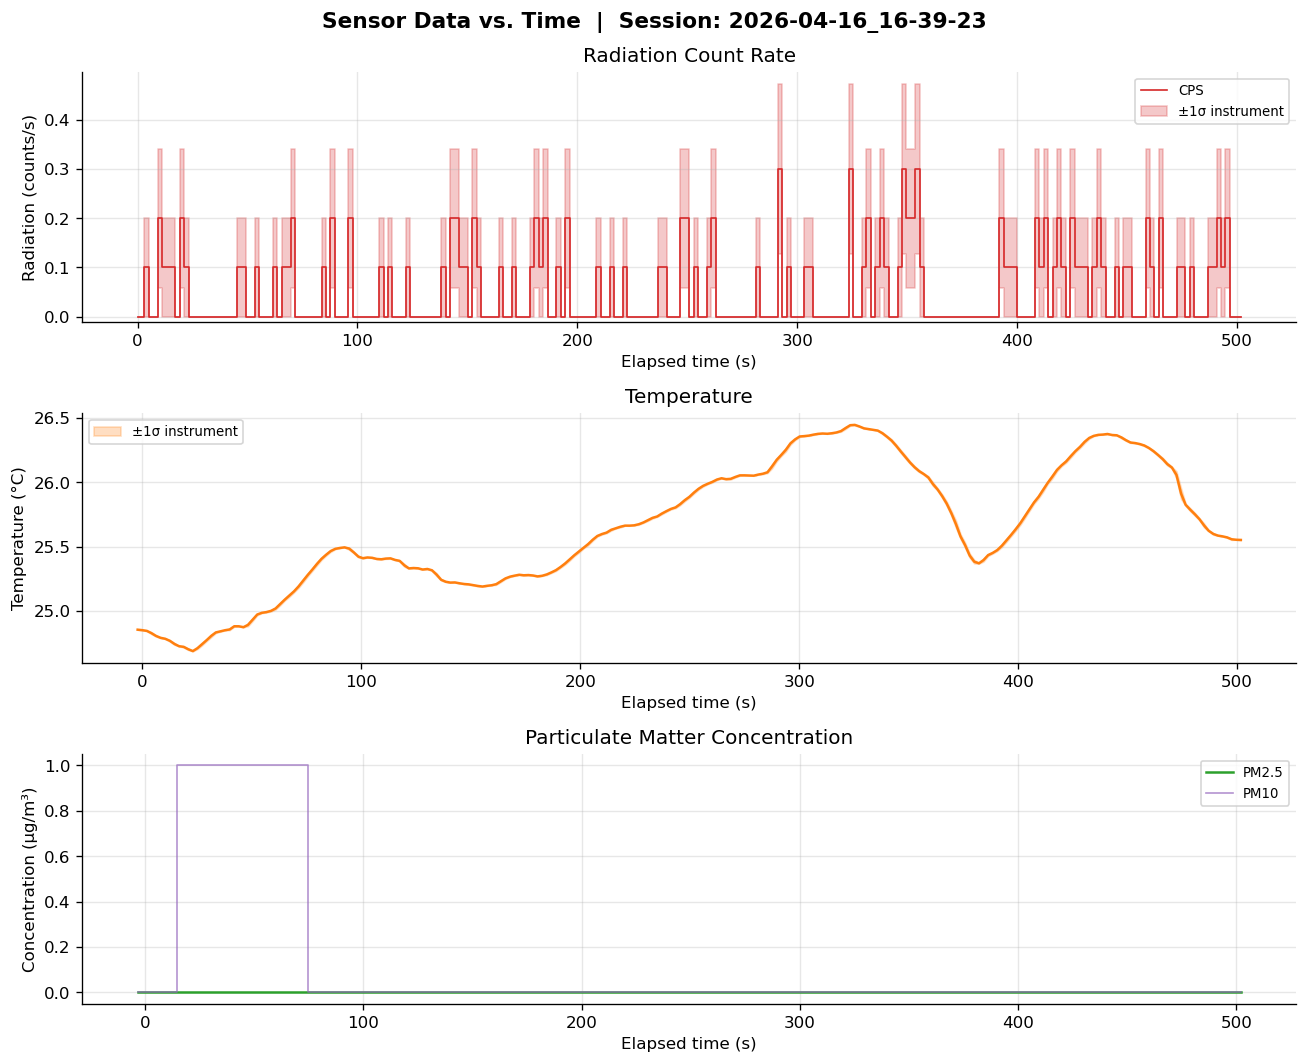

Saved: fig1_timeseries.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9))
fig.suptitle(f'Sensor Data vs. Time  |  Session: {session["start_time"]}', 
             fontsize=13, fontweight='bold')

# ── Radiation ──
ax = axes[0]
ax.step(rad['t'], rad['cps'], color='#d62728', linewidth=1, where='mid', label='CPS')
ax.fill_between(rad['t'],
                rad['cps'] - rad['cps_err'],
                rad['cps'] + rad['cps_err'],
                alpha=0.25, color='#d62728', step='mid', label='±1σ instrument')
ax.set_ylabel('Radiation (counts/s)')
ax.set_xlabel('Elapsed time (s)')
ax.set_title('Radiation Count Rate')
ax.legend(fontsize=8)
ax.set_ylim(bottom=-0.01)

# ── Temperature ──
ax = axes[1]
ax.plot(pth['t'], pth['temp_mean'], color='#ff7f0e', linewidth=1.5)
ax.fill_between(pth['t'],
                pth['temp_mean'] - pth['temp_err'],
                pth['temp_mean'] + pth['temp_err'],
                alpha=0.25, color='#ff7f0e', label='±1σ instrument')
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel('Elapsed time (s)')
ax.set_title('Temperature')
ax.legend(fontsize=8)

# ── PM2.5 (and PM10 if available) ──
ax = axes[2]
ax.step(aq['t'], aq['pm25_mean'], color='#2ca02c', linewidth=1.5,
        where='mid', label='PM2.5')
if 'pm10_mean' in aq.columns:
    ax.step(aq['t'], aq['pm10_mean'], color='#9467bd', linewidth=1,
            where='mid', alpha=0.7, label='PM10')
ax.set_ylabel('Concentration (μg/m³)')
ax.set_xlabel('Elapsed time (s)')
ax.set_title('Particulate Matter Concentration')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Q27 — Histograms, mean, standard deviation, normality

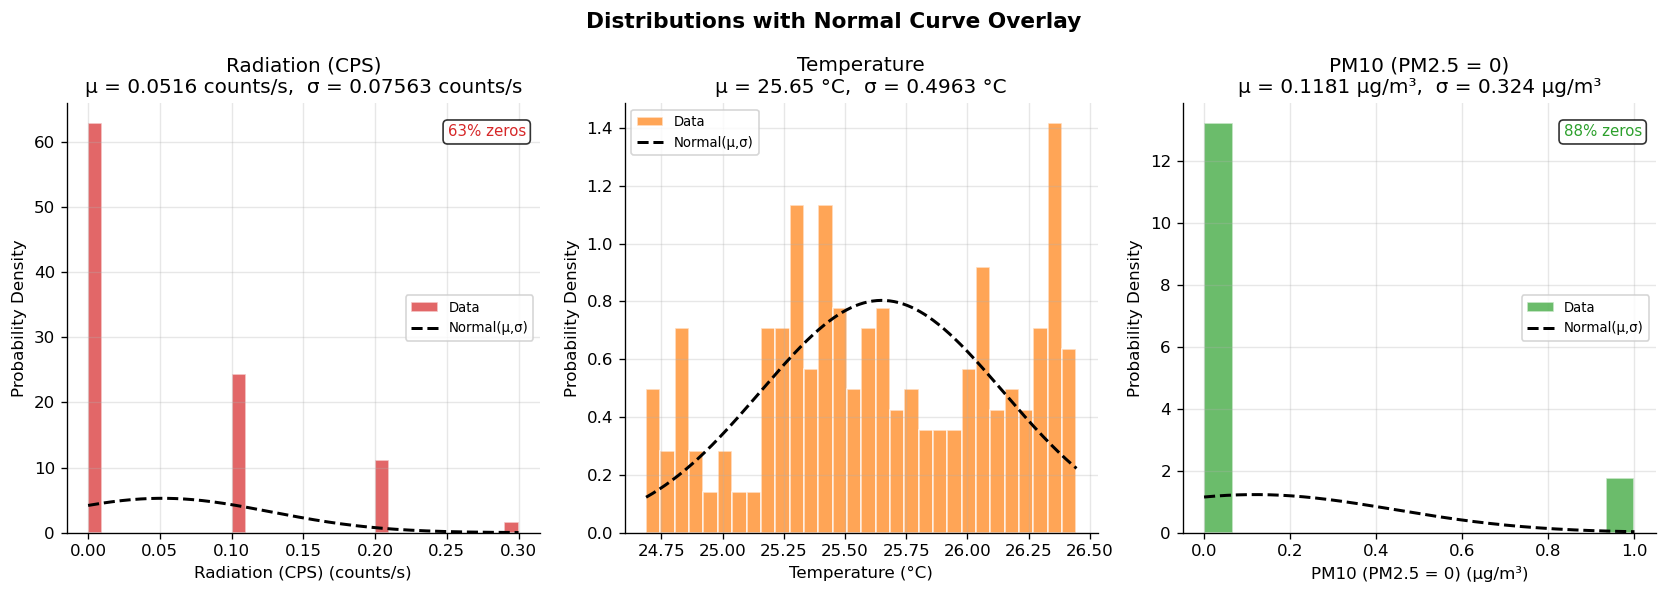

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Distributions with Normal Curve Overlay', fontsize=13, fontweight='bold')

datasets = [
    (axes[0], rad['cps'].values,        'Radiation (CPS)',      '#d62728', 'counts/s'),
    (axes[1], pth['temp_mean'].values,  'Temperature',          '#ff7f0e', '°C'),
    (axes[2], aq['pm25_mean'].values,   'PM2.5',                '#2ca02c', 'μg/m³'),
]

for ax, data, label, color, unit in datasets:
    mu, sigma = data.mean(), data.std(ddof=1)
    
    # Use PM10 if PM2.5 is all-zero (more informative)
    if label == 'PM2.5' and np.all(data == 0) and 'pm10_mean' in aq.columns:
        data  = aq['pm10_mean'].values
        label = 'PM10 (PM2.5 = 0)'
        mu, sigma = data.mean(), data.std(ddof=1)
    
    n_bins = max(10, min(30, len(data)//8))
    counts_hist, bins, _ = ax.hist(data, bins=n_bins, color=color,
                                   alpha=0.7, edgecolor='white',
                                   density=True, label='Data')
    
    # Overlay normal PDF
    x = np.linspace(bins[0], bins[-1], 400)
    if sigma > 0:
        ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', lw=1.8,
                label=f'Normal(μ,σ)')
    
    frac_zero = (data == 0).mean()
    ax.set_xlabel(f'{label} ({unit})')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'{label}\nμ = {mu:.4g} {unit},  σ = {sigma:.4g} {unit}')
    ax.legend(fontsize=8)
    if frac_zero > 0.05:
        ax.text(0.97, 0.95, f'{100*frac_zero:.0f}% zeros',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9, color=color,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics table
def summarize(name, data, unit=''):
    n = len(data)
    mu = data.mean()
    sigma = data.std(ddof=1)
    _, p_sw = stats.shapiro(data[:min(len(data), 200)])  # Shapiro-Wilk limit
    return {'Quantity': name, 'N': n,
            f'Mean ({unit})': f'{mu:.5g}',
            f'Std Dev ({unit})': f'{sigma:.5g}',
            'Shapiro-Wilk p': f'{p_sw:.4f}',
            'Normal?': 'likely' if p_sw > 0.05 else 'NO (p < 0.05)'}

pm_data = aq['pm10_mean'].values if np.all(aq['pm25_mean'].values == 0) else aq['pm25_mean'].values
pm_label = 'PM10' if np.all(aq['pm25_mean'].values == 0) else 'PM2.5'

summary = pd.DataFrame([
    summarize('Radiation (CPS)', rad['cps'].values, 'counts/s'),
    summarize('Temperature', pth['temp_mean'].values, '°C'),
    summarize(pm_label, pm_data, 'μg/m³'),
])
print('\n── Summary Statistics ──')
display(summary)


── Summary Statistics ──


,Quantity,N,Mean (counts/s),Std Dev (counts/s),Shapiro-Wilk p,Normal?,Mean (°C),Std Dev (°C),Mean (μg/m³),Std Dev (μg/m³)
0,Radiation (CPS),250,0.0516,0.075633,0.0000,NO (p < 0.05),NaN,NaN,NaN,NaN
1,Temperature,241,NaN,NaN,0.0000,NO (p < 0.05),25.65,0.49634,NaN,NaN
2,PM10,127,NaN,NaN,0.0000,NO (p < 0.05),NaN,NaN,0.11811,0.32402


---
## Q28 — Counting statistics: expected vs. measured variance

For Poisson-distributed counts, the **expected variance equals the mean**: $\sigma^2_{\text{expected}} = \mu$

We convert CPS → raw counts by multiplying by the integration time $T$.

In [ ]:
counts = rad['counts'].values   # raw counts per integration window
N      = len(counts)

mu_counts         = counts.mean()
var_measured      = counts.var(ddof=1)
std_measured      = counts.std(ddof=1)

var_expected      = mu_counts          # Poisson: σ² = μ
std_expected      = np.sqrt(mu_counts) # Poisson: σ  = √μ

print(f'Integration time T = {T_int} s')
print(f'N measurements     = {N}')
print()
print(f'Mean raw counts (μ)        = {mu_counts:.4f} counts per {T_int}s window')
print()
print(f'Expected variance (= μ)    = {var_expected:.4f}')
print(f'Measured variance          = {var_measured:.4f}')
print(f'Ratio meas/expected        = {var_measured/var_expected:.4f}')
print()
print(f'Expected σ = √μ            = {std_expected:.4f}')
print(f'Measured σ                 = {std_measured:.4f}')
print(f'Ratio σ_meas / σ_expected  = {std_measured/std_expected:.4f}')

Integration time T = 10 s
N measurements     = 250

Mean raw counts (μ)        = 0.5160 counts per 10s window

Expected variance (= μ)    = 0.5160
Measured variance          = 0.5720
Ratio meas/expected        = 1.1086

Expected σ = √μ            = 0.7183
Measured σ                 = 0.7563
Ratio σ_meas / σ_expected  = 1.0529


---
## Q29 — CLT uncertainty on the measured standard deviation

From the Central Limit Theorem:
$$\sigma_\sigma = \frac{\sigma}{\sqrt{2N}}$$

This tells us how precisely we know our measured $\sigma$.

In [ ]:
sigma_sigma = std_measured / np.sqrt(2 * N)

# Uncertainty on the mean
sigma_mean_empirical = std_measured / np.sqrt(N)
sigma_mean_poisson   = np.sqrt(mu_counts / N)   # Poisson: Var(μ̂) = μ/N

# How many σ_σ does the discrepancy represent?
discrepancy = abs(std_measured - std_expected)
tension     = discrepancy / sigma_sigma

print(f'Measured σ                   = {std_measured:.5f}')
print(f'CLT uncertainty on σ (σ_σ)   = {sigma_sigma:.5f}')
print(f'Measured σ ± σ_σ             = [{std_measured-sigma_sigma:.4f}, {std_measured+sigma_sigma:.4f}]')
print()
print(f'Expected σ (√μ)              = {std_expected:.5f}')
print(f'Discrepancy |meas - exp|     = {discrepancy:.5f}')
print(f'Tension in σ_σ units         = {tension:.2f} σ_σ')
print()
if tension < 2:
    print(f'✓  Tension < 2 σ_σ → measured and expected σ are statistically consistent.')
else:
    print(f'⚠  Tension > 2 σ_σ → measured σ significantly exceeds Poisson expectation.')
print()
print(f'Uncertainty on mean (empirical, σ/√N):   {sigma_mean_empirical:.5f} counts')
print(f'Uncertainty on mean (Poisson, √μ/√N):    {sigma_mean_poisson:.5f} counts')
print(f'Mean ± σ_mean = {mu_counts:.4f} ± {sigma_mean_empirical:.4f} counts per {T_int}s')

Measured σ                   = 0.75633
CLT uncertainty on σ (σ_σ)   = 0.03382
Measured σ ± σ_σ             = [0.7225, 0.7902]

Expected σ (√μ)              = 0.71833
Discrepancy |meas - exp|     = 0.03800
Tension in σ_σ units         = 1.12 σ_σ

✓  Tension < 2 σ_σ → measured and expected σ are statistically consistent.

Uncertainty on mean (empirical, σ/√N):   0.04783 counts
Uncertainty on mean (Poisson, √μ/√N):    0.04543 counts
Mean ± σ_mean = 0.5160 ± 0.0478 counts per 10s


---
## Q30 — Excess variation beyond counting statistics?

In [ ]:
excess_var  = var_measured - var_expected
excess_frac = excess_var / var_expected * 100

# Index of dispersion (Fano factor) — should be 1.0 for pure Poisson
fano = var_measured / mu_counts

print(f'Fano factor (= var/mean, expected = 1.0 for Poisson): {fano:.4f}')
print(f'Excess variance (meas - expected):  {excess_var:.5f}  ({excess_frac:+.1f}%)')
print(f'Tension in σ_σ units:               {tension:.2f}')
print()
if tension < 2:
    print('Conclusion: No statistically significant excess variation.')
    print('The measured variance is consistent with pure Poisson counting statistics')
    print('within the precision of this dataset.')
else:
    print('Conclusion: Statistically significant excess variation detected.')
    print('Possible causes:')
    print('  • Physical: movement through environments with different true count rates')
    print('  • Geophysical: spatial variation in radon, soil radioactivity, building materials')
    print('  • Instrumental: sensor dead time, integration-window jitter')
    print('  • Statistical: non-stationarity (mixture of Poisson processes → over-dispersion)')

Fano factor (= var/mean, expected = 1.0 for Poisson): 1.1086
Excess variance (meas - expected):  0.05603  (+10.9%)
Tension in σ_σ units:               1.12

Conclusion: No statistically significant excess variation.
The measured variance is consistent with pure Poisson counting statistics
within the precision of this dataset.


---
## Q31 — Location comparison (if location data is available)

If you manually tagged your walk with location labels, add a `location` column to `radiation.csv`  
or define time intervals below. Otherwise this cell shows the overall mean uncertainty.

In [ ]:
# ── Option A: define time-based location windows ──────────────────────────────
# Edit these to match your actual walk segments (in seconds from start).
# Set to None to skip the location comparison.

LOCATIONS = None   # e.g. [('Hallway', 0, 120), ('Outside', 120, 300), ('Lab', 300, 500)]

# ── Option B: if radiation.csv already has a 'location' column ────────────────
HAS_LOCATION_COLUMN = 'location' in rad.columns

# ─────────────────────────────────────────────────────────────────────────────

if HAS_LOCATION_COLUMN:
    groups = {loc: rad[rad['location'] == loc]['counts'].values
              for loc in rad['location'].unique()}
elif LOCATIONS is not None:
    groups = {name: rad[(rad['t'] >= t0) & (rad['t'] < t1)]['counts'].values
              for name, t0, t1 in LOCATIONS}
else:
    groups = None

if groups is not None:
    print(f'{Location:<20} {N:>5} {Mean (counts):>15} {σ_mean:>12} {Mean +- σ_mean}')
    print('-' * 70)
    results = []
    for name, data in groups.items():
        n = len(data)
        mu = data.mean()
        sigma_m = data.std(ddof=1) / np.sqrt(n)
        print(f'{name:<20} {n:>5} {mu:>15.4f} {sigma_m:>12.4f}   {mu:.4f} +- {sigma_m:.4f}')
        results.append((name, mu, sigma_m))
    
    print('\nPairwise z-scores (|μ₁ - μ₂| / √(σ₁² + σ₂²)):')
    for i, (n1, m1, s1) in enumerate(results):
        for j, (n2, m2, s2) in enumerate(results):
            if j > i:
                z = abs(m1 - m2) / np.sqrt(s1**2 + s2**2)
                sig = '✓ significant' if z > 2 else '— not significant'
                print(f'  {n1} vs {n2}: z = {z:.2f}  {sig}')
else:
    print('No location data provided.')
    print(f'Overall: mean = {mu_counts:.4f} +- {sigma_mean_empirical:.4f} counts per {T_int}s')
    print()
    print('To compare locations, define time windows in the LOCATIONS variable above:')
    print("  LOCATIONS = [('Location A', 0, 120), ('Location B', 120, 300), ...]")

No location data provided.
Overall: mean = 0.5160 +- 0.0478 counts per 10s

To compare locations, define time windows in the LOCATIONS variable above:
  LOCATIONS = [('Location A', 0, 120), ('Location B', 120, 300), ...]


---
## Bonus — Poisson vs. Normal overlay on radiation histogram

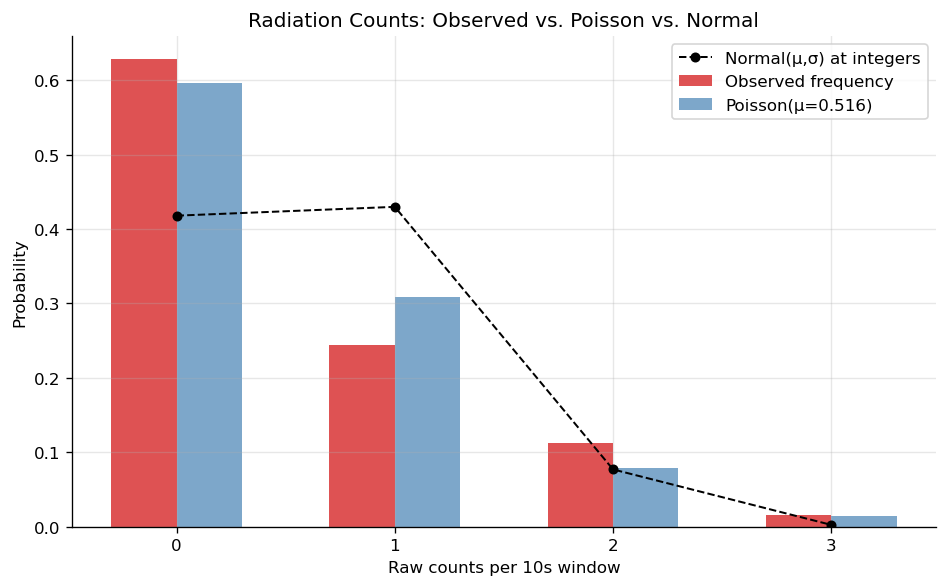

In [ ]:
from scipy.stats import poisson

fig, ax = plt.subplots(figsize=(8, 5))

# Histogram of raw integer counts
int_counts = np.round(counts).astype(int)
unique_vals = np.arange(0, int_counts.max() + 1)
observed_freq = np.array([(int_counts == k).mean() for k in unique_vals])

ax.bar(unique_vals - 0.15, observed_freq, width=0.3, color='#d62728',
       alpha=0.8, label='Observed frequency')

# Poisson PMF
poisson_pmf = poisson.pmf(unique_vals, mu_counts)
ax.bar(unique_vals + 0.15, poisson_pmf, width=0.3, color='steelblue',
       alpha=0.7, label=f'Poisson(μ={mu_counts:.3f})')

# Normal PDF evaluated at integer points
normal_pmf = stats.norm.pdf(unique_vals, mu_counts, std_measured)
ax.plot(unique_vals, normal_pmf, 'ko--', ms=5, lw=1.2,
        label=f'Normal(μ,σ) at integers')

ax.set_xlabel(f'Raw counts per {T_int}s window')
ax.set_ylabel('Probability')
ax.set_title('Radiation Counts: Observed vs. Poisson vs. Normal')
ax.legend()
ax.set_xticks(unique_vals)
plt.tight_layout()
plt.show()

In [ ]:
# Final summary printout
print('=' * 55)
print('  FINAL STATISTICAL SUMMARY')
print('=' * 55)
print(f'  Integration time T         = {T_int} s')
print(f'  N measurements             = {N}')
print(f'  Mean counts/window (μ)     = {mu_counts:.5f}')
print(f'  Measured σ                 = {std_measured:.5f}')
print(f'  Expected σ = √μ            = {std_expected:.5f}')
print(f'  Fano factor (var/mean)     = {fano:.4f}  (ideal Poisson = 1.0)')
print(f'  σ_σ = σ/√(2N)              = {sigma_sigma:.5f}')
print(f'  Tension                    = {tension:.2f} σ_σ')
print(f'  σ_mean = σ/√N              = {sigma_mean_empirical:.5f}')
print(f'  Mean ± σ_mean              = {mu_counts:.4f} ± {sigma_mean_empirical:.4f} counts/{T_int}s')
print('=' * 55)

  FINAL STATISTICAL SUMMARY
  Integration time T         = 10 s
  N measurements             = 250
  Mean counts/window (μ)     = 0.51600
  Measured σ                 = 0.75633
  Expected σ = √μ            = 0.71833
  Fano factor (var/mean)     = 1.1086  (ideal Poisson = 1.0)
  σ_σ = σ/√(2N)              = 0.03382
  Tension                    = 1.12 σ_σ
  σ_mean = σ/√N              = 0.04783
  Mean ± σ_mean              = 0.5160 ± 0.0478 counts/10s
